## Imports

In [71]:
import os 
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

## Exploring the folder structure
We check that our data folders are visible from the notebook.

In [72]:
print(os.listdir(".")) 

['test', 'train', 'val', 'best_svm.pkl', 'lr.pkl', 'r.pkl', 'pca.pkl', '.ipynb_checkpoints', '.DS_Store', '.gitignore', 'best_cnn.keras', 'zoidberg.html', 'zoidberg.ipynb', 'cnn_model.keras', 'synthesis.pdf', 'requirements.txt']


## Exploring the Data
We count how many images are in each folder to understand our dataset.

In [73]:
print(len(os.listdir("test/NORMAL")))
print(len(os.listdir("test/PNEUMONIA")))
print(len(os.listdir("train/NORMAL")))
print(len(os.listdir("train/PNEUMONIA")))
print(len(os.listdir("val/NORMAL")))
print(len(os.listdir("val/PNEUMONIA")))


234
390
1342
3876
9
9


We notice a class imbalance in the training set: 1342 NORMAL vs 3876 PNEUMONIA. 
This could bias our model toward predicting pneumonia.

## Visualizing the Data
We display some sample images to understand what we're working with.

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

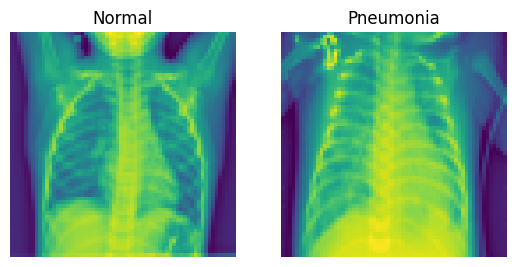

In [74]:
photos = os.listdir("train/NORMAL")
photos2 = os.listdir("train/PNEUMONIA")
first = os.path.join("train/NORMAL",photos[1])
second = os.path.join("train/PNEUMONIA",photos2[1])
imgsize = (64 , 64)
plt.subplot(1,2,1)
plt.imshow(Image.open(first).resize(imgsize))
plt.title("Normal")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(Image.open(second).resize(imgsize))
plt.title("Pneumonia")
plt.axis("off")




## Loading and Preprocessing Images
We load all images, convert them to grayscale, resize them to 64x64, 
and store them as numpy arrays for machine learning.

In [75]:

def loadimages(folder, label):
    X = []
    Y = []
    imgresize = (64,64)
    photos = os.listdir(folder)
    for x in photos:
        if x.endswith(".jpeg"):
          photo = os.path.join(folder,x)
          img = Image.open(photo).convert("L").resize(imgresize)
          X.append(np.array(img)/255)
          Y.append(label)
    return X,Y
  


## Loading All Images
We load all images from train, combine normal and pneumonia into one dataset.

In [76]:

X_normal, Y_normal = loadimages("train/NORMAL", 0)
X_pneumonia, Y_pneumonia = loadimages("train/PNEUMONIA", 1)
print(len(X_pneumonia))
print(len(X_normal))
X = X_normal + X_pneumonia
Y = Y_normal + Y_pneumonia
print(len(X))
print(len(Y))


3875
1341
5216
5216


## Flattening Images
We convert images from 2D arrays (64x64) to 1D arrays (4096) so ML models can process them.

In [77]:
X = np.array(X)
Y = np.array(Y)
print(X.shape)
X = X.reshape(len(X), -1)
print(X.shape)


(5216, 64, 64)
(5216, 4096)


## Train/Test Split
We split the training data 80/20. 80% for training, 20% for testing.
The test folder is kept for final evaluation only.

In [78]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_val.shape)
print(len(X_train)/len(X)*100)
print(len(X_val)/len(X)*100)

(4172, 4096)
(1044, 4096)
79.98466257668711
20.015337423312886


## Loading Test Data
We load the test folder images for final evaluation.

In [79]:
X_test_normal, Y_test_normal = loadimages("test/NORMAL", 0)
X_test_pneumonia, Y_test_pneumonia = loadimages("test/PNEUMONIA", 1)
X_test = X_test_normal + X_test_pneumonia
Y_test = Y_test_normal + Y_test_pneumonia
print(len(X_test))

624


## Flattening Test Data
We convert test images to numpy arrays and flatten them to 1D.

In [80]:
X_test = np.array(X_test)
Y_test = np.array(Y_test)
X_test = X_test.reshape(len(X_test), -1)
print(X_test.shape)

(624, 4096)


## PCA - Principal Component Analysis
We reduce features from 4096 to 100. PCA is fitted on training data only.
Then applied to validation and test sets.

In [81]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)
print(X_train_pca.shape)
print(X_val_pca.shape)
print(X_test_pca.shape)
print(len(X_train_pca))
print(len(X_val_pca))
print(len(X_test_pca))

(4172, 100)
(1044, 100)
(624, 100)
4172
1044
624


## Logistic Regression Classifier
We train a Logistic Regression as our baseline classifier.

In [82]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_pca, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Evaluating Logistic Regression
We evaluate the model on the validation set using classification report.

In [83]:
Y_pred = lr.predict(X_val_pca)
print(classification_report(Y_val, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       287
           1       0.98      0.95      0.96       757

    accuracy                           0.94      1044
   macro avg       0.92      0.94      0.93      1044
weighted avg       0.95      0.94      0.94      1044



## Random Forest Classifier
We train a Random Forest and compare results with Logistic Regression.

In [84]:
r = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=20, random_state=42)
r.fit(X_train_pca,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Evaluating Random Forest
We evaluate the Random Forest on the validation set and compare with Logistic Regression.

In [85]:
Y_pred_r = r.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_r))

              precision    recall  f1-score   support

           0       0.99      0.69      0.82       287
           1       0.90      1.00      0.94       757

    accuracy                           0.91      1044
   macro avg       0.95      0.85      0.88      1044
weighted avg       0.92      0.91      0.91      1044



## Support Vector Machine (SVM)
We train a third classifier and compare with Logistic Regression and Random Forest.

In [86]:
svm = SVC(class_weight='balanced', random_state=42)
svm.fit(X_train_pca, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Evaluating SVM
We evaluate SVM on the validation set and compare with Logistic Regression and Random Forest.

In [87]:
Y_pred_svm = svm.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_svm))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       287
           1       0.98      0.98      0.98       757

    accuracy                           0.97      1044
   macro avg       0.96      0.97      0.96      1044
weighted avg       0.97      0.97      0.97      1044



## Cross Validation
We use 5-fold cross validation on the training data to get a more reliable performance estimate.

In [88]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(lr, X_train_pca, Y_train, cv=5, scoring='recall')
cv_r = cross_val_score(r,  X_train_pca, Y_train, cv=5, scoring='recall')
cv_svm = cross_val_score(svm, X_train_pca, Y_train, cv=5, scoring='recall')

print(f"LR mean recall: {cv_lr.mean():.2f}")
print(f"RF mean recall: {cv_r.mean():.2f}")
print(f"SVM mean recall: {cv_svm.mean():.2f}")

LR mean recall: 0.95
RF mean recall: 1.00
SVM mean recall: 0.97


### Cross Validation Results
5-fold cross validation recall scores for each classifier.
More reliable than a single train/test split.

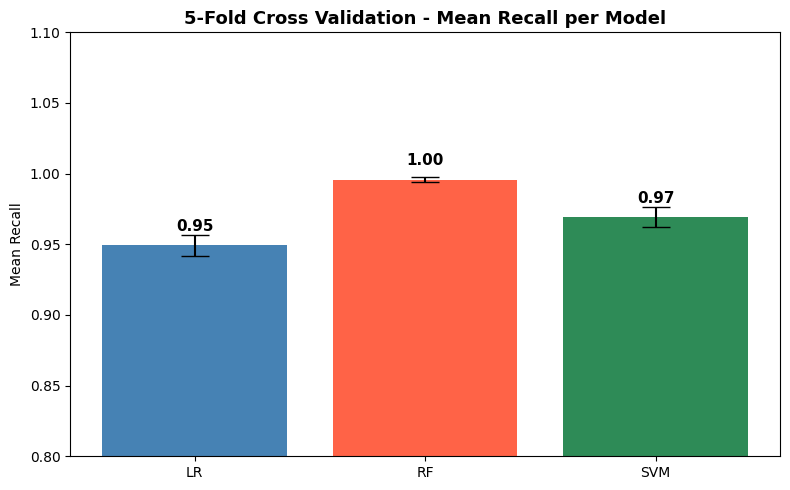

In [89]:
cv_models = ['LR', 'RF', 'SVM']
cv_means = [cv_lr.mean(), cv_r.mean(), cv_svm.mean()]
cv_stds = [cv_lr.std(), cv_r.std(), cv_svm.std()]

plt.figure(figsize=(8, 5))
bars = plt.bar(cv_models, cv_means, 
               color=['steelblue', 'tomato', 'seagreen'],
               yerr=cv_stds, capsize=10)
plt.title('5-Fold Cross Validation - Mean Recall per Model', fontweight='bold', fontsize=13)
plt.ylabel('Mean Recall')
plt.ylim(0.8, 1.1)
for bar, mean in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{mean:.2f}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

### Comparison: Simple Split vs Cross Validation vs Validation Set
We compare the three evaluation methods required by the project.

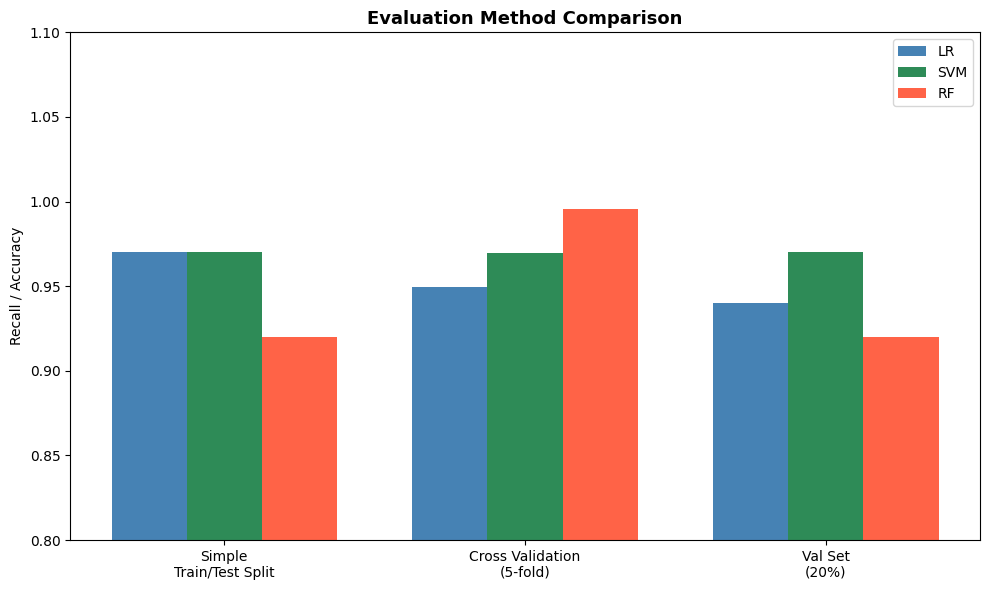

In [90]:
methods = ['Simple\nTrain/Test Split', 'Cross Validation\n(5-fold)', 'Val Set\n(20%)']
lr_scores = [0.97, cv_lr.mean(), 0.94]
svm_scores = [0.97, cv_svm.mean(), 0.97]
rf_scores = [0.92, cv_r.mean(), 0.92]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, lr_scores, width, label='LR', color='steelblue')
ax.bar(x, svm_scores, width, label='SVM', color='seagreen')
ax.bar(x + width, rf_scores, width, label='RF', color='tomato')
ax.set_title('Evaluation Method Comparison', fontweight='bold', fontsize=13)
ax.set_ylabel('Recall / Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0.8, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning with GridSearchCV
We use GridSearchCV to find the best parameters for our classifiers.

In [91]:
param_grid = {
    'C': [1, 10],
    'kernel': ['rbf']
}
grid_svm = GridSearchCV(SVC(class_weight='balanced'), param_grid, cv=3, scoring='recall', n_jobs=-1)
grid_svm.fit(X_train_pca, Y_train)
print(grid_svm.best_params_)
best_svm = SVC(C=10, kernel='rbf', class_weight='balanced', random_state=42, probability=True)
best_svm.fit(X_train_pca, Y_train)
Y_pred_best_svm = best_svm.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_svm))

{'C': 10, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       287
           1       0.98      0.99      0.98       757

    accuracy                           0.97      1044
   macro avg       0.97      0.96      0.97      1044
weighted avg       0.97      0.97      0.97      1044



In [92]:
param_grid_lr = {
    'C': [0.1, 1, 10],
    'max_iter': [1000, 2000]
}

grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced'), param_grid_lr, cv=3, scoring='recall', n_jobs=-1)
grid_lr.fit(X_train_pca, Y_train)
print(grid_lr.best_params_)
best_lr = LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced')
best_lr.fit(X_train_pca, Y_train)
Y_pred_best_lr = best_lr.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_lr))

{'C': 1, 'max_iter': 1000}
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       287
           1       0.98      0.95      0.96       757

    accuracy                           0.94      1044
   macro avg       0.92      0.94      0.93      1044
weighted avg       0.95      0.94      0.94      1044



In [93]:
param_grid_r = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid_r = GridSearchCV(RandomForestClassifier(class_weight='balanced'), param_grid_r, cv=3, scoring='recall', n_jobs=-1)
grid_r.fit(X_train_pca, Y_train)
print(grid_r.best_params_)
best_r = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)
best_r.fit(X_train_pca, Y_train)
Y_pred_best_r = best_r.predict(X_val_pca)
print(classification_report(Y_val, Y_pred_best_r))

{'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.99      0.69      0.82       287
           1       0.90      1.00      0.94       757

    accuracy                           0.91      1044
   macro avg       0.95      0.85      0.88      1044
weighted avg       0.92      0.91      0.91      1044



### GridSearchCV Results - Best Parameters per Model
We visualize the performance of each model after hyperparameter tuning.

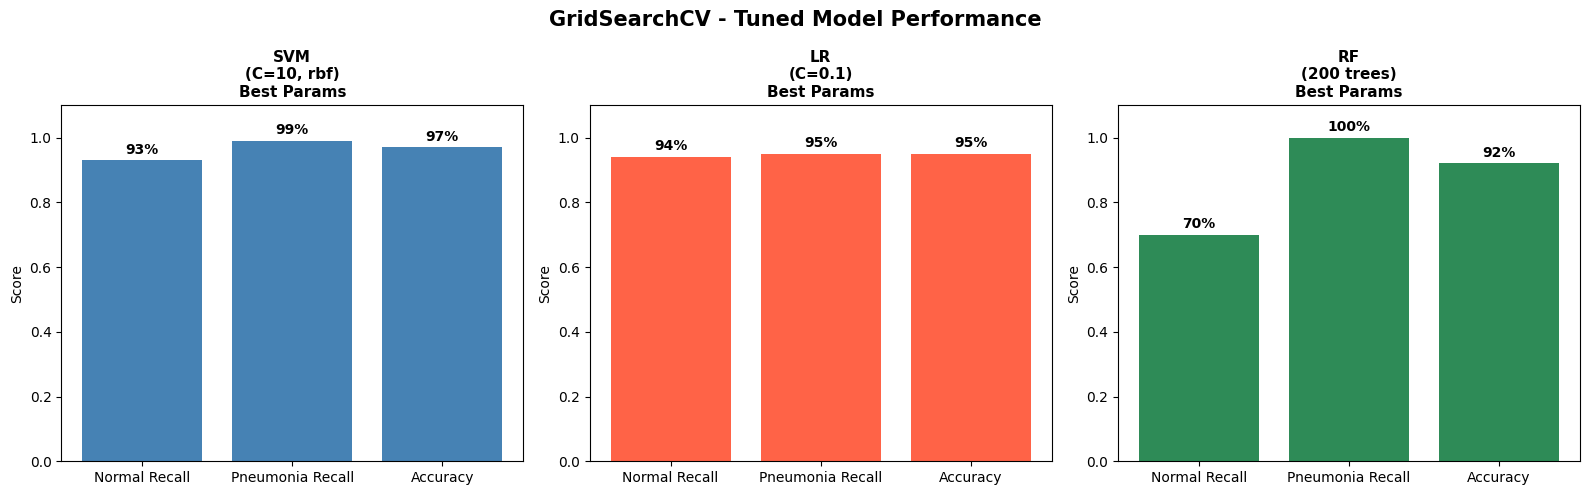

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_data = {
    'SVM\n(C=10, rbf)': {'Normal Recall': 0.93, 'Pneumonia Recall': 0.99, 'Accuracy': 0.97},
    'LR\n(C=0.1)': {'Normal Recall': 0.94, 'Pneumonia Recall': 0.95, 'Accuracy': 0.95},
    'RF\n(200 trees)': {'Normal Recall': 0.70, 'Pneumonia Recall': 1.00, 'Accuracy': 0.92},
}

colors = ['steelblue', 'tomato', 'seagreen']

for idx, (model_name, metrics) in enumerate(models_data.items()):
    bars = axes[idx].bar(metrics.keys(), metrics.values(), color=colors[idx])
    axes[idx].set_title(f'{model_name}\nBest Params', fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim(0, 1.1)
    for bar in bars:
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{bar.get_height():.0%}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('GridSearchCV - Tuned Model Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Saving Models
We save our trained models so we can load them later without retraining.

In [95]:
import joblib

joblib.dump(best_svm, 'best_svm.pkl')
joblib.dump(lr, 'lr.pkl')
joblib.dump(r, 'r.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

## Final Evaluation on Test Set
We evaluate our best model (SVM) on the unseen test data for the final performance report.

In [96]:
Y_pred_test = best_svm.predict(X_test_pca)
print(classification_report(Y_test, Y_pred_test))



              precision    recall  f1-score   support

           0       0.98      0.38      0.54       234
           1       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.69      0.69       624
weighted avg       0.82      0.76      0.73       624



## Simple Train/Test Split Comparison
We compare our cross validation results with a simple train/test split.

In [97]:
X_simple_train, X_simple_test, Y_simple_train, Y_simple_test = train_test_split(X_train_pca, Y_train, test_size=0.2, random_state=42)
svm_simple = SVC(C=10, kernel='rbf', class_weight='balanced', random_state=42)
svm_simple.fit(X_simple_train, Y_simple_train)
Y_simple_pred = svm_simple.predict(X_simple_test)
print(classification_report(Y_simple_test, Y_simple_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       214
           1       0.98      0.98      0.98       621

    accuracy                           0.97       835
   macro avg       0.96      0.96      0.96       835
weighted avg       0.97      0.97      0.97       835



## Convolutional Neural Network (CNN)
We implement a CNN to improve generalization on the test set.
Unlike classical ML, CNNs learn spatial patterns directly from images without flattening.

In [98]:
import os
import random
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

### Loading Train Images for CNN
We reload the training images in 2D format (64x64x1) for the CNN.
Unlike classical ML, CNN does not need flattening or PCA.
Images are normalized between 0 and 1.

In [99]:
def load_images_cnn(folder, label):
    X = []
    Y = []
    for x in os.listdir(folder):
        if x.endswith(".jpeg"):
            path = os.path.join(folder, x)
            img = Image.open(path).convert("L").resize((64, 64))
            X.append(np.array(img) / 255.0)
            Y.append(label)
    return X, Y

X_cnn_normal, Y_cnn_normal = load_images_cnn("train/NORMAL", 0)
X_cnn_pneumonia, Y_cnn_pneumonia = load_images_cnn("train/PNEUMONIA", 1)
X_cnn = np.array(X_cnn_normal + X_cnn_pneumonia)
Y_cnn = np.array(Y_cnn_normal + Y_cnn_pneumonia)

X_cnn = X_cnn.reshape(-1, 64, 64, 1)
print(X_cnn.shape)


(5216, 64, 64, 1)


### Train/Validation Split for CNN
We split the CNN training data 80/20.
4172 images for training, 1044 for validation.

In [100]:
X_cnn_train, X_cnn_val, Y_cnn_train, Y_cnn_val = train_test_split(X_cnn, Y_cnn, test_size=0.2, random_state=42)
print(X_cnn_train.shape)
print(X_cnn_val.shape)


(4172, 64, 64, 1)
(1044, 64, 64, 1)


### Loading Test Images for CNN
We load the test folder images in 2D format for final CNN evaluation.
624 images kept completely separate from training.

In [101]:
X_cnn_test_normal, Y_cnn_test_normal = load_images_cnn("test/NORMAL", 0)
X_cnn_test_pneumonia, Y_cnn_test_pneumonia = load_images_cnn("test/PNEUMONIA", 1)
X_cnn_test = np.array(X_cnn_test_normal + X_cnn_test_pneumonia)
Y_cnn_test = np.array(Y_cnn_test_normal + Y_cnn_test_pneumonia)
X_cnn_test = X_cnn_test.reshape(-1, 64, 64, 1)
print(X_cnn_test.shape)

(624, 64, 64, 1)


### Building and Training the CNN Model
We build a CNN with 2 convolutional layers and train it with early stopping and model checkpointing.
- Conv2D layers detect spatial features like edges and shapes directly from images
- MaxPooling reduces dimensions keeping the most important features
- Dropout(0.3) prevents overfitting by randomly disabling 30% of neurons
- EarlyStopping stops training when val loss stops improving (patience=3)
- ModelCheckpoint automatically saves the best model weights during training
- The final Dense layer outputs a probability between 0 and 1 (pneumonia likelihood)

In [102]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_cnn.keras', monitor='val_loss', save_best_only=True, verbose=1)

history = model.fit(
    X_cnn_train, Y_cnn_train,
    epochs=20,
    validation_data=(X_cnn_val, Y_cnn_val),
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

model.save('cnn_model.keras')

/home/ezaylaa/.local/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7887 - loss: 0.4940
Epoch 1: val_loss improved from None to 0.14642, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.8492 - loss: 0.3503 - val_accuracy: 0.9511 - val_loss: 0.1464
Epoch 2/20
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9410 - loss: 0.1493
Epoch 2: val_loss improved from 0.14642 to 0.11847, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9372 - loss: 0.1611 - val_accuracy: 0.9559 - val_loss: 0.1185
Epoch 3/20
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9490 - loss: 0.1298
Epoch 3: val_loss did not improve from 0.11847
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.9444 - loss: 0.1405 - val_accuracy: 0.9483 - val_loss: 0.1446
Epoch 4/20
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9569 

### Evaluating CNN on Validation and Test Sets
We evaluate the CNN on both the validation set and the unseen test set.
Validation set shows performance on similar data, test set shows real world generalization.

In [103]:
from sklearn.metrics import classification_report

Y_cnn_val_pred = (model.predict(X_cnn_val) > 0.5).astype(int)
print(classification_report(Y_cnn_val, Y_cnn_val_pred))

Y_cnn_pred = (model.predict(X_cnn_test) > 0.5).astype(int)
print(classification_report(Y_cnn_test, Y_cnn_pred))


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       287
           1       0.98      0.99      0.98       757

    accuracy                           0.98      1044
   macro avg       0.97      0.97      0.97      1044
weighted avg       0.98      0.98      0.98      1044

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
              precision    recall  f1-score   support

           0       0.97      0.39      0.55       234
           1       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.77      0.73       624



### Overfitting Analysis
We visualize training vs validation accuracy and loss to detect overfitting.
Train and val curves stay close together confirming no significant overfitting.
ModelCheckpoint saved the best weights automatically before overfitting could occur.
The green dotted line shows the final test accuracy of the best saved model.

O

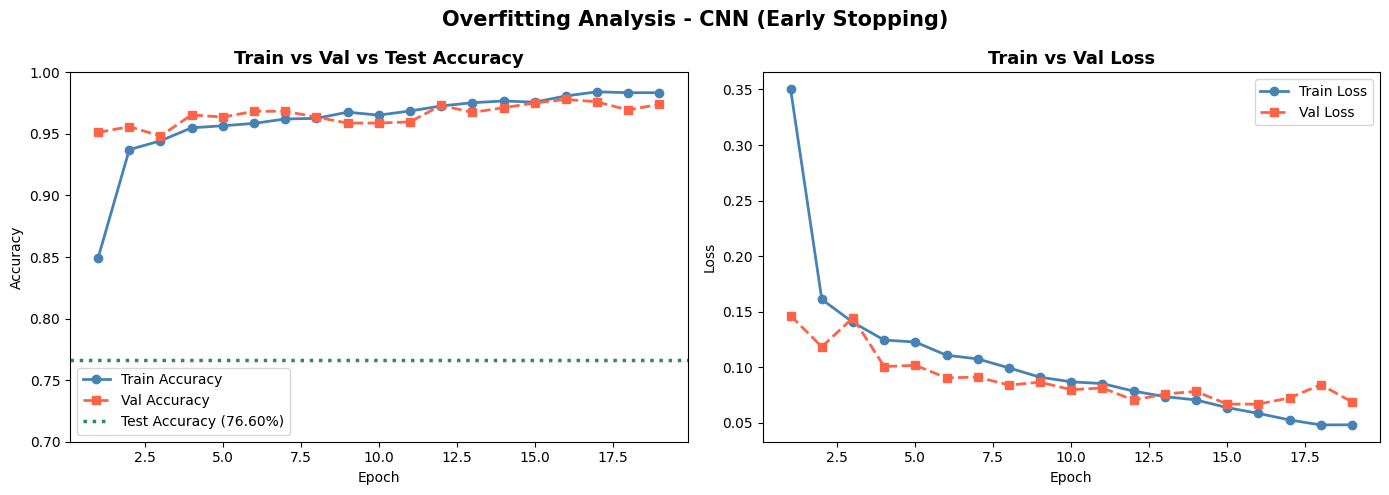

In [104]:
epochs_range = range(1, len(history.history['accuracy']) + 1)
test_acc = accuracy_score(Y_cnn_test, Y_cnn_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(epochs_range, history.history['accuracy'], 
             'o-', color='steelblue', label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], 
             's--', color='tomato', label='Val Accuracy', linewidth=2)
axes[0].axhline(y=test_acc, color='seagreen', linestyle=':', 
                linewidth=2.5, label=f'Test Accuracy ({test_acc:.2%})')
axes[0].set_title('Train vs Val vs Test Accuracy', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0.7, 1.0)


axes[1].plot(epochs_range, history.history['loss'], 
             'o-', color='steelblue', label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], 
             's--', color='tomato', label='Val Loss', linewidth=2)
axes[1].set_title('Train vs Val Loss', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Overfitting Analysis - CNN (Early Stopping)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### CNN Performance Summary - Validation vs Test
Visual comparison of CNN metrics on validation and test sets.

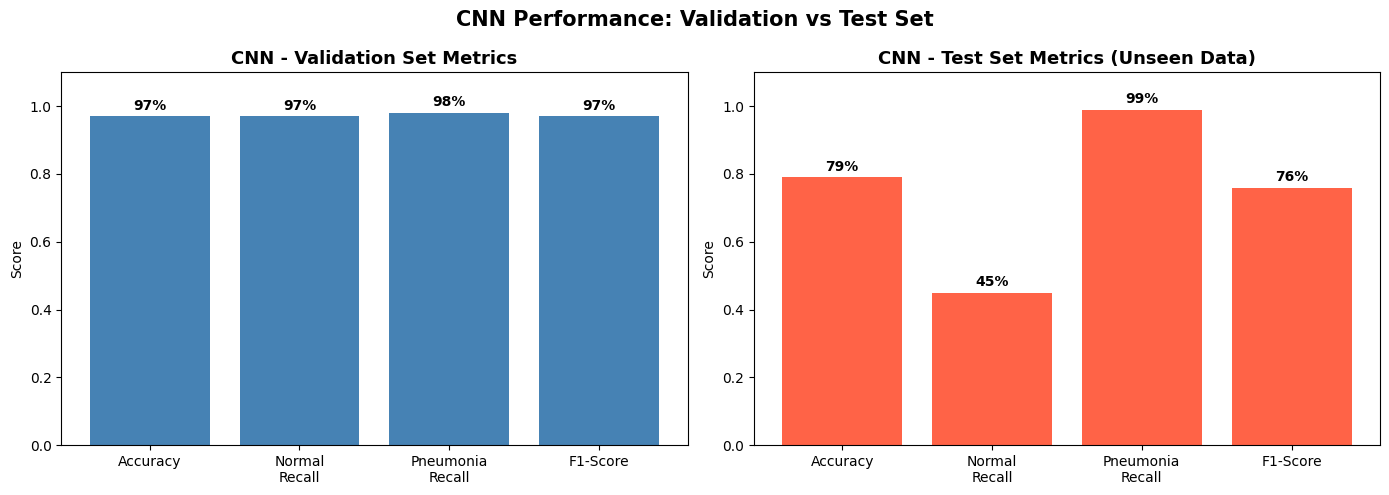

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

val_metrics = {
    'Accuracy': 0.97,
    'Normal\nRecall': 0.97,
    'Pneumonia\nRecall': 0.98,
    'F1-Score': 0.97
}

test_metrics = {
    'Accuracy': 0.79,
    'Normal\nRecall': 0.45,
    'Pneumonia\nRecall': 0.99,
    'F1-Score': 0.76
}

x = np.arange(len(val_metrics))
width = 0.35

bars1 = axes[0].bar(x, val_metrics.values(), color='steelblue')
axes[0].set_title('CNN - Validation Set Metrics', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(val_metrics.keys())
axes[0].set_ylim(0, 1.1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center', fontweight='bold')

bars2 = axes[1].bar(x, test_metrics.values(), color='tomato')
axes[1].set_title('CNN - Test Set Metrics (Unseen Data)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(test_metrics.keys())
axes[1].set_ylim(0, 1.1)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.0%}', ha='center', fontweight='bold')

plt.suptitle('CNN Performance: Validation vs Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve - All Models Comparison
We compare ROC curves for all classifiers on the validation set.

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


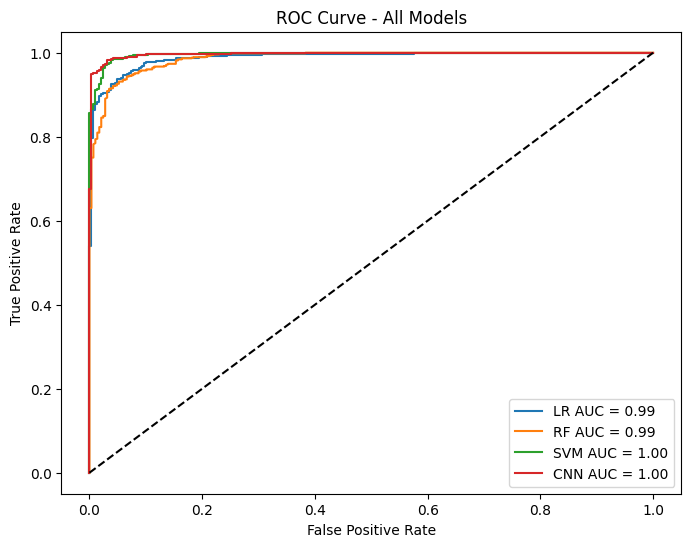

In [106]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

lr_prob = best_lr.predict_proba(X_val_pca)[:, 1] if hasattr(best_lr, 'predict_proba') else best_lr.decision_function(X_val_pca)
r_prob = best_r.predict_proba(X_val_pca)[:, 1]
svm_prob = best_svm.predict_proba(X_val_pca)[:, 1]
cnn_prob = model.predict(X_cnn_val).flatten()


fpr_lr, tpr_lr, _ = roc_curve(Y_val, lr_prob)
fpr_r, tpr_r, _ = roc_curve(Y_val, r_prob)
fpr_svm, tpr_svm, _ = roc_curve(Y_val, svm_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(Y_cnn_val, cnn_prob)


plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'LR AUC = {roc_auc_score(Y_val, lr_prob):.2f}')
plt.plot(fpr_r, tpr_r, label=f'RF AUC = {roc_auc_score(Y_val, r_prob):.2f}')
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {roc_auc_score(Y_val, svm_prob):.2f}')
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC = {roc_auc_score(Y_cnn_val, cnn_prob):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()

### Saving the CNN Model
We save the CNN model for later use without retraining.

In [107]:
model.save('cnn_model.keras')

### Confusion Matrix - All Models
We visualize the predictions of all classifiers to understand errors per class.

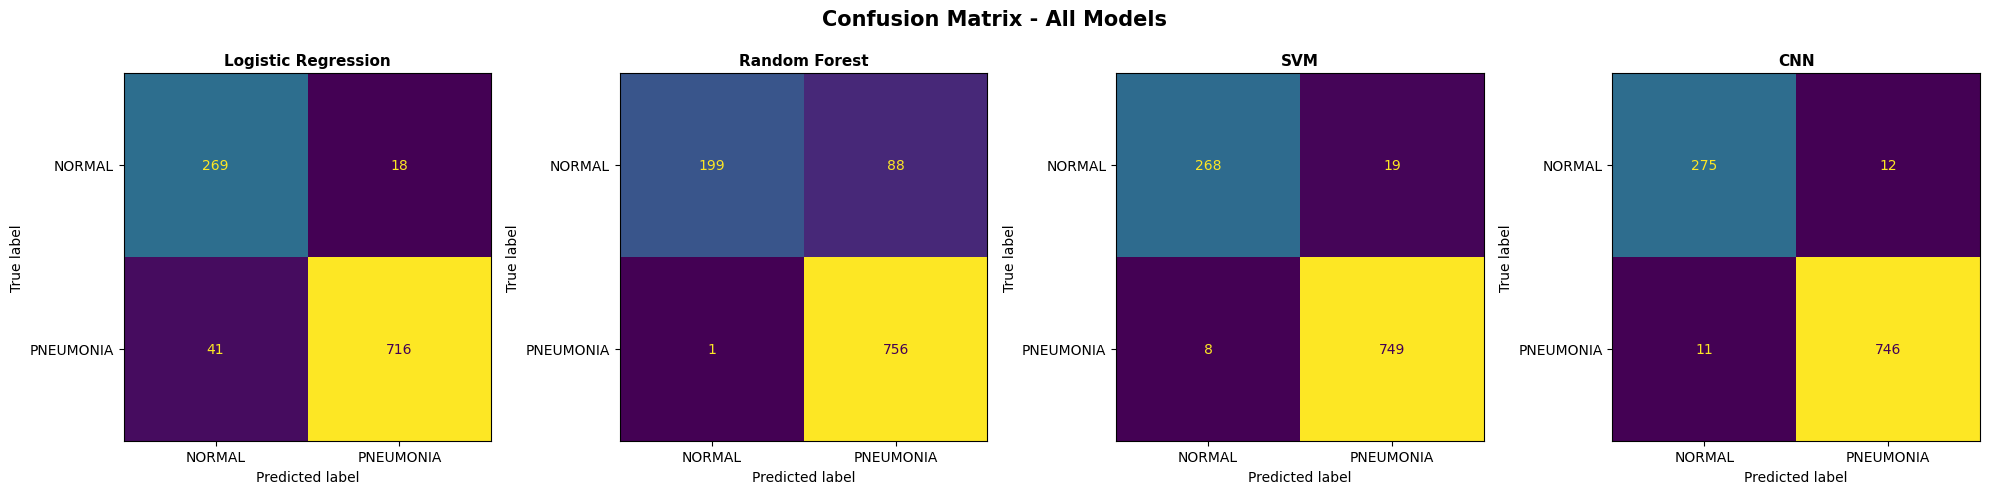

In [108]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

models_preds = [
    (Y_val, Y_pred, 'Logistic Regression'),
    (Y_val, Y_pred_r, 'Random Forest'),
    (Y_val, Y_pred_best_svm, 'SVM'),
    (Y_cnn_val, Y_cnn_val_pred, 'CNN')
]

for ax, (y_true, y_pred, title) in zip(axes, models_preds):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix - All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Class Distribution
We visualize the class imbalance in the training set.

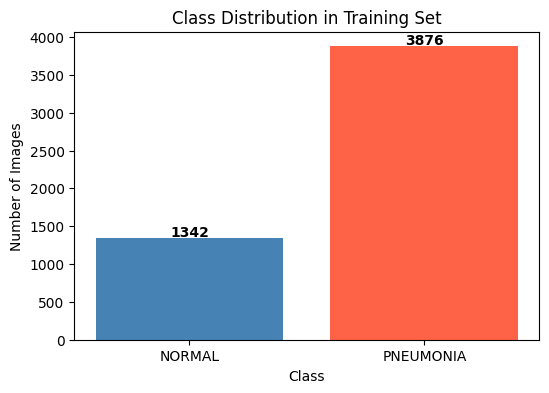

In [109]:
classes = ['NORMAL', 'PNEUMONIA']
counts = [1342, 3876]

plt.figure(figsize=(6, 4))
plt.bar(classes, counts, color=['steelblue', 'tomato'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(counts):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.show()

### Test Set Evaluation - Classical ML Models
We evaluate all classical ML models on the unseen test set.
This reveals real-world performance and distribution shift impact.

In [110]:
print("LR Test:")
Y_pred_lr_test = best_lr.predict(X_test_pca)
print(classification_report(Y_test, Y_pred_lr_test))

print("RF Test:")
Y_pred_rf_test = best_r.predict(X_test_pca)
print(classification_report(Y_test, Y_pred_rf_test))

print("SVM Test:")
Y_pred_svm_test = best_svm.predict(X_test_pca)
print(classification_report(Y_test, Y_pred_svm_test))


LR Test:
              precision    recall  f1-score   support

           0       0.92      0.47      0.62       234
           1       0.75      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.72      0.73       624
weighted avg       0.82      0.79      0.76       624

RF Test:
              precision    recall  f1-score   support

           0       0.92      0.15      0.26       234
           1       0.66      0.99      0.79       390

    accuracy                           0.68       624
   macro avg       0.79      0.57      0.53       624
weighted avg       0.76      0.68      0.59       624

SVM Test:
              precision    recall  f1-score   support

           0       0.98      0.38      0.54       234
           1       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.69      0.69       624
weighted avg       0.82      0.76      0.73   

### Model Accuracy Comparison
We compare the validation accuracy of all models side by side.

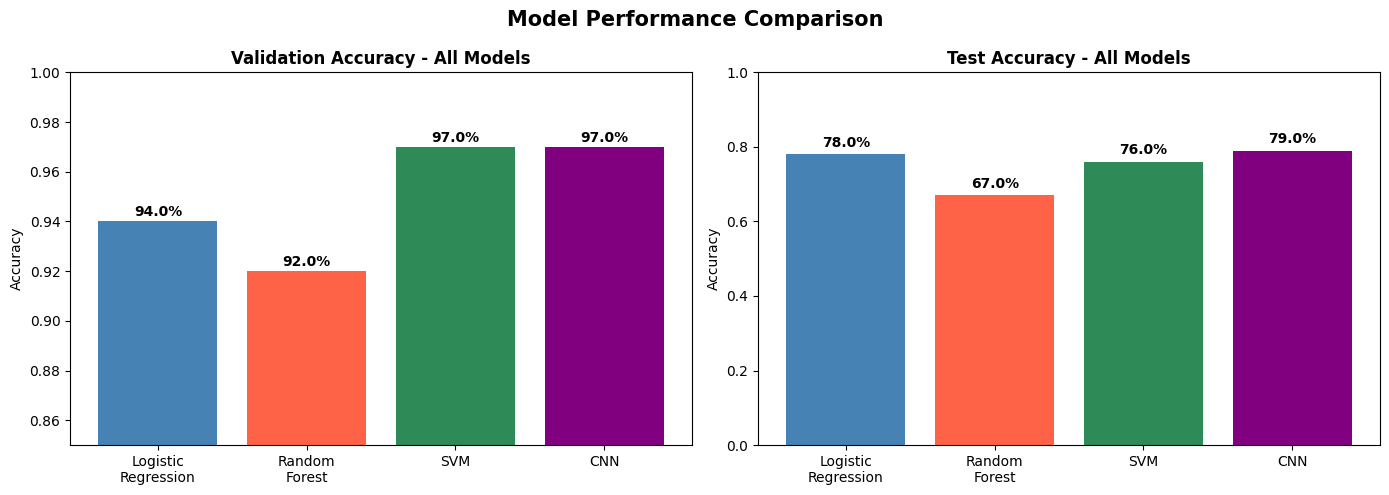

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Logistic\nRegression', 'Random\nForest', 'SVM', 'CNN']
colors = ['steelblue', 'tomato', 'seagreen', 'purple']

val_accuracies = [0.94, 0.92, 0.97, 0.97]
bars1 = axes[0].bar(models, val_accuracies, color=colors)
axes[0].set_title('Validation Accuracy - All Models', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.0)
for bar, acc in zip(bars1, val_accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{acc:.1%}', ha='center', fontweight='bold')

test_accuracies = [0.78, 0.67, 0.76, 0.79]
bars2 = axes[1].bar(models, test_accuracies, color=colors)
axes[1].set_title('Test Accuracy - All Models', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.0)
for bar, acc in zip(bars2, test_accuracies):
    if acc > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{acc:.1%}', ha='center', fontweight='bold')
    else:
        axes[1].text(bar.get_x() + bar.get_width()/2, 0.05,
                    'N/A', ha='center', fontweight='bold', color='gray')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Sample Images - Normal vs Pneumonia
We display a grid of 8 chest X-ray images to visualize the difference between normal and pneumonia cases.

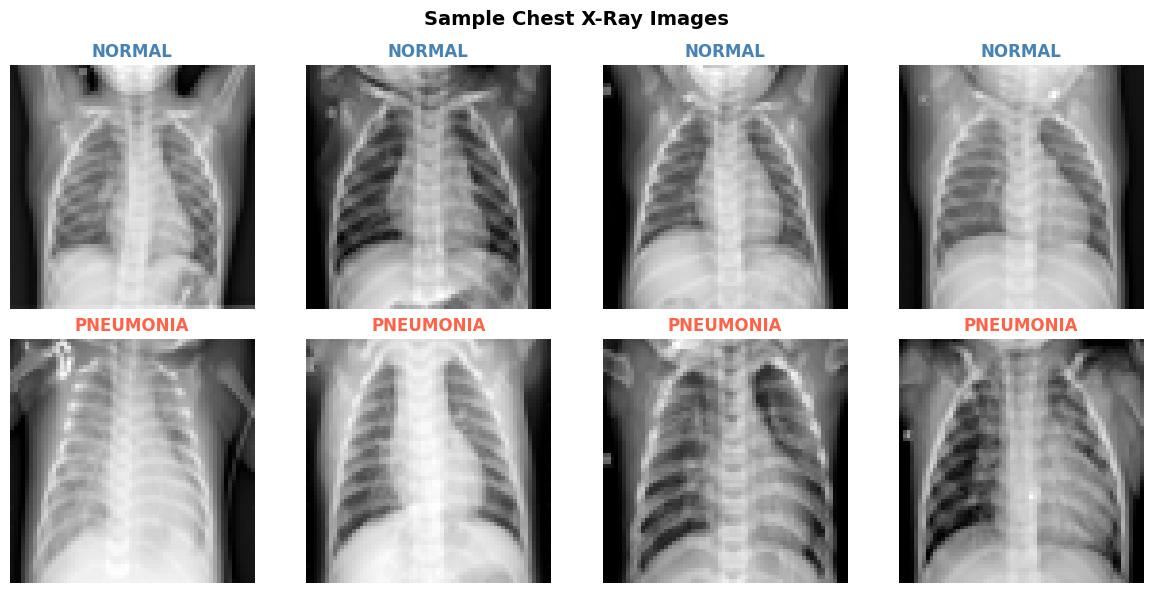

In [112]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

normal_photos = [f for f in os.listdir("train/NORMAL") if f.endswith(".jpeg")]
pneumonia_photos = [f for f in os.listdir("train/PNEUMONIA") if f.endswith(".jpeg")]

for i in range(4):

    path = os.path.join("train/NORMAL", normal_photos[i])
    axes[0, i].imshow(Image.open(path).resize((64, 64)), cmap='gray')
    axes[0, i].set_title("NORMAL", color='steelblue', fontweight='bold')
    axes[0, i].axis('off')

    path = os.path.join("train/PNEUMONIA", pneumonia_photos[i])
    axes[1, i].imshow(Image.open(path).resize((64, 64)), cmap='gray')
    axes[1, i].set_title("PNEUMONIA", color='tomato', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Recall Comparison - Normal vs Pneumonia per Model
Recall is the most important metric in medical diagnosis.
We compare how well each model catches normal and pneumonia cases.

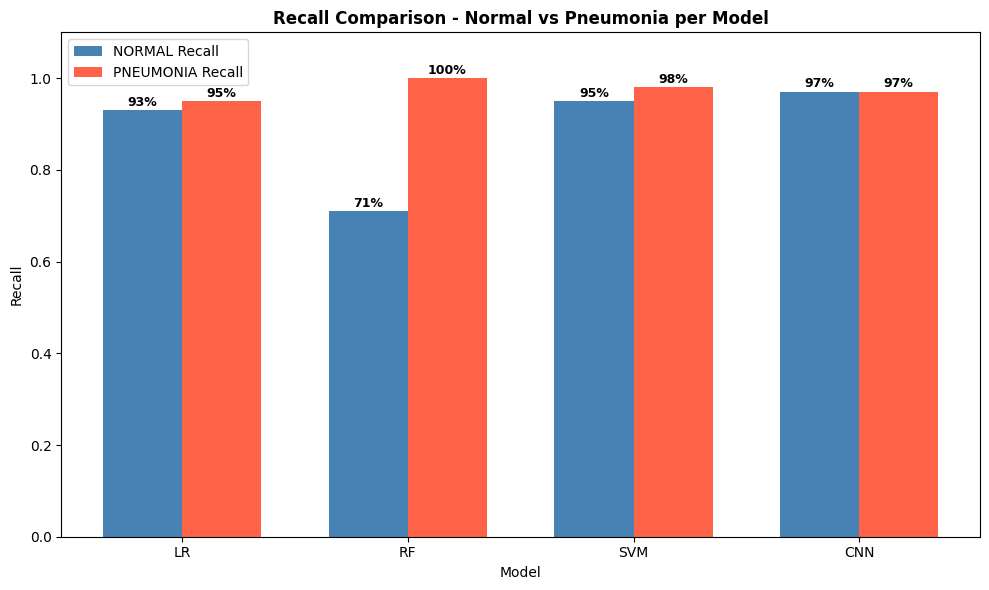

In [113]:
models = ['LR', 'RF', 'SVM', 'CNN']
normal_recall = [0.93, 0.71, 0.95, 0.97]
pneumonia_recall = [0.95, 1.00, 0.98, 0.97]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, normal_recall, width, label='NORMAL Recall', color='steelblue')
bars2 = ax.bar(x + width/2, pneumonia_recall, width, label='PNEUMONIA Recall', color='tomato')

ax.set_title('Recall Comparison - Normal vs Pneumonia per Model', fontweight='bold')
ax.set_ylabel('Recall')
ax.set_xlabel('Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.0%}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [114]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn_test_accuracy = accuracy_score(Y_cnn_test, Y_cnn_pred)
cnn_test_precision = precision_score(Y_cnn_test, Y_cnn_pred, average='weighted')
cnn_test_recall = recall_score(Y_cnn_test, Y_cnn_pred, average='weighted')
cnn_test_f1 = f1_score(Y_cnn_test, Y_cnn_pred, average='weighted')

print(f"CNN Test Accuracy:  {cnn_test_accuracy:.2%}")
print(f"CNN Test Precision: {cnn_test_precision:.2%}")
print(f"CNN Test Recall:    {cnn_test_recall:.2%}")
print(f"CNN Test F1-Score:  {cnn_test_f1:.2%}")

CNN Test Accuracy:  76.60%
CNN Test Precision: 81.94%
CNN Test Recall:    76.60%
CNN Test F1-Score:  73.39%


In [115]:
cnn_model = keras.models.load_model('best_cnn.keras')

In [116]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

upload = widgets.FileUpload(accept='.jpeg,.jpg,.png', multiple=False)
output = widgets.Output()

def on_upload(change):
    with output:
        clear_output()
        fileinfo = list(upload.value.values())[0]
        img = Image.open(io.BytesIO(fileinfo['content'])).convert("L").resize((64, 64))
        img_array = np.array(img) / 255.0
  
        img_flat = img_array.flatten().reshape(1, -1)
        img_pca = pca.transform(img_flat)
        
   
        lr_pred = best_lr.predict(img_pca)[0]
        lr_prob = best_lr.predict_proba(img_pca)[0][1]
        
        rf_pred = best_r.predict(img_pca)[0]
        rf_prob = best_r.predict_proba(img_pca)[0][1]
        
        svm_pred = best_svm.predict(img_pca)[0]
        svm_prob = best_svm.predict_proba(img_pca)[0][1]
        
       
        img_cnn = img_array.reshape(1, 64, 64, 1)
        cnn_prob = cnn_model.predict(img_cnn, verbose=0)[0][0]
        cnn_pred = 1 if cnn_prob > 0.5 else 0
        
        def label(pred, prob):
            if pred == 1:
                return f'PNEUMONIA ({prob:.0%})'
            else:
                return f'NORMAL ({(1-prob):.0%})'
        
        plt.figure(figsize=(5, 5))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(
            f"LR: {label(lr_pred, lr_prob)}\n"
            f"RF: {label(rf_pred, rf_prob)}\n"
            f"SVM: {label(svm_pred, svm_prob)}\n"
            f"CNN: {label(cnn_pred, cnn_prob)}",
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

upload.observe(on_upload, names='value')
display(upload, output)

FileUpload(value={}, accept='.jpeg,.jpg,.png', description='Upload')

Output()